# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [7]:
dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j * Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## frank2d

In [8]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))

import math

N = 50

In [9]:
frank2d = Frank2D(N, rout)

In [10]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [11]:
u_gridded, v_gridded = frank2d.gridded_data['u'], frank2d.gridded_data['v']
q_gridded = np.hypot(u_gridded, v_gridded)
print(np.sort(q_gridded)/1e4)
print(q_gridded.min(), q_gridded.max())

[  0.          10.31324031  10.31324031 ... 357.40995204 357.40995204
 364.62810804]
0.0 3646281.0804362795


In [54]:
best_N50 = best_N50_Rmax3 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [80]:
ls = [9e3, 1e4, 2e4, 4e4, 5e4, best_N50_Rmax3['l'], 1e5]

In [81]:
params_0 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[0] }
params_1 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[1] }
params_2 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[2] }
params_3 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[3] }
params_4 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[4] }
params_5 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[5] }
params_6 = { 'm': best_N50['m'], 'c': best_N50['c'], 'l': ls[6] }

In [82]:
params = [params_0, params_1, params_2, params_3, params_4, params_5, params_6]

### Study first the kernels

In [90]:
param = params_6

In [91]:
tick_positions_y = [0, 700,1000,  1500]
tick_labels_y = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N+1}$",
    r"$(u, v)_{N^{2}}$",
]

tick_positions_x = [0, 700,  1500]
tick_labels_x = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N^{2}}$",
]

In [92]:
u, v = frank2d.FT.uv_points_unshifted
u1, u2 = np.meshgrid(u_gridded, u_gridded)
v1, v2 = np.meshgrid(v_gridded, v_gridded)

In [93]:
def factorSE(params):
    m = params['m']
    c = params['c']
    q1 = np.hypot(u1, v1)
    q2 = np.hypot(u2, v2)
    min_freq = np.sort(np.abs(np.unique(v)))[1]

    def power_spectrum(q, m, c):
        q[q == 0] = min_freq
        return (q**m)* c

    p1 = power_spectrum(q1, m, c)
    p2 = power_spectrum(q2, m, c)
    
    factor = np.sqrt(p1 * p2)
    return factor


In [94]:
factor = factorSE(param)

In [95]:
from matplotlib.colors import PowerNorm, LogNorm, SymLogNorm

### SE Kernel

In [96]:
def SE(params): 
    l = params['l']
    SE_Kernel = np.exp(-0.5*((u1-u2)**2 + (v1-v2)**2)/ l**2)
    return SE_Kernel

In [97]:
matrixSE = SE(param) #* factor

In [98]:
np.max(matrixSE)

1.0

In [99]:
np.array_equal(matrixSE, matrixSE.T)

True

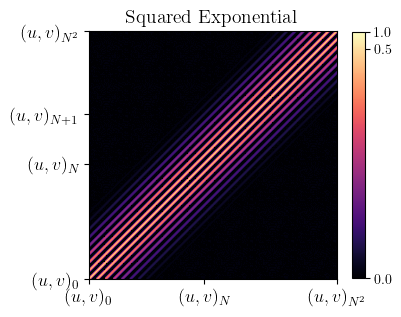

In [101]:
plt.figure(figsize=(4,4))

vmin_val = matrixSE.min()
vmax_val = matrixSE.max()
mid_val = (vmin_val + vmax_val) / 2

im = plt.imshow(matrixSE, origin='lower',
                cmap='magma', 
                norm=PowerNorm(gamma=0.1, vmin=vmin_val, vmax=vmax_val))

plt.xticks(tick_positions_x, tick_labels_x, size=13)
plt.yticks(tick_positions_y, tick_labels_y, size=13)

cbar = plt.colorbar(im, shrink=0.8, ticks=[vmin_val, mid_val, vmax_val])

plt.xlim(0, 1500)
plt.ylim(0, 1500)
plt.title(r'Squared Exponential', size=14)
plt.show()

<Figure size 640x480 with 0 Axes>

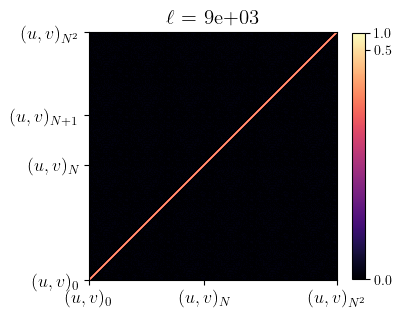

<Figure size 640x480 with 0 Axes>

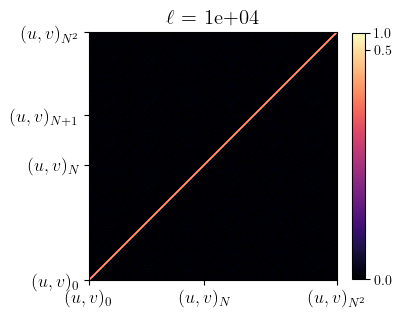

<Figure size 640x480 with 0 Axes>

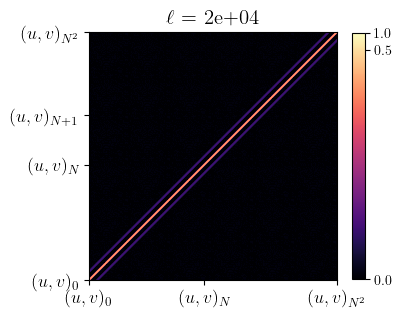

<Figure size 640x480 with 0 Axes>

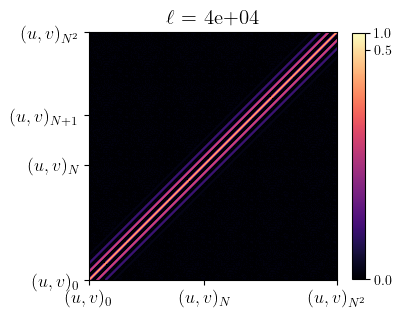

<Figure size 640x480 with 0 Axes>

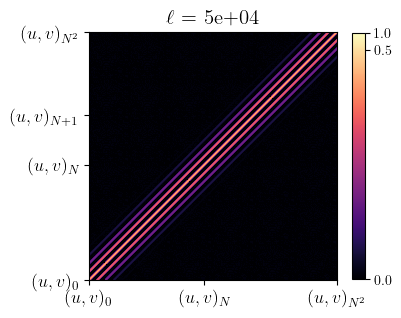

<Figure size 640x480 with 0 Axes>

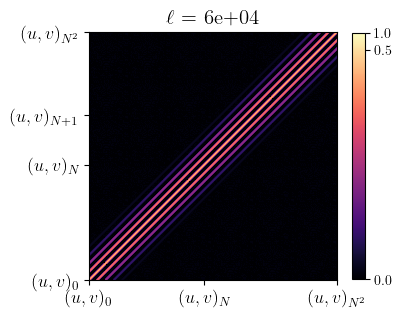

In [75]:
for param in params:
        matrixSE = SE(param)
        plt.clf()
        plt.figure(figsize=(4,4))

        vmin_val = matrixSE.min()
        vmax_val = matrixSE.max()
        mid_val = (vmin_val + vmax_val) / 2


        im = plt.imshow(matrixSE, origin='lower',
                        cmap='magma', 
                        norm=PowerNorm(gamma=0.1, vmin=vmin_val, vmax=vmax_val))

        plt.xticks(tick_positions_x, tick_labels_x, size=13)
        plt.yticks(tick_positions_y, tick_labels_y, size=13)

        cbar = plt.colorbar(im, shrink=0.8, ticks=[vmin_val, mid_val, vmax_val])

        plt.xlim(0, 1500)
        plt.ylim(0, 1500)
        plt.title(r'SE', size=15)
        plt.title(r'$\ell$ = ' + f'{param['l']:.0e} ', size = 15)
        plt.show()

### Wendland

In [102]:
def P_k(r, k):
    if k == 0:
        return np.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3
    else:
        raise ValueError("k must be 0, 1, or 2.")

def Wendland(l):
    j = 4
    k = 1
    H = 2*1.897367*l
    r = np.sqrt(((u1-u2)/H)**2 + ((v1-v2)/H)**2)
    r_normalized = r
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0
    return   factor * P_k(r_normalized, k)

In [106]:
matrixW = Wendland(param['l'])#*factor

In [107]:
np.array_equal(matrixW, matrixW.T)

True

<Figure size 640x480 with 0 Axes>

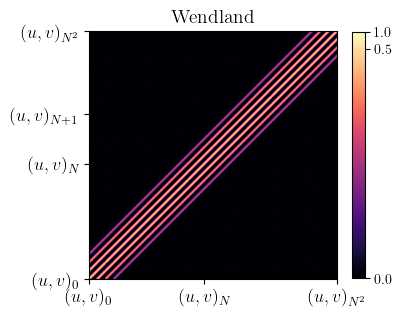

In [109]:
plt.clf()
plt.figure(figsize=(4,4))

vmin_val = matrixSE.min()
vmax_val = matrixSE.max()
mid_val = (vmin_val + vmax_val) / 2


im = plt.imshow(matrixW, origin='lower',
                cmap='magma', 
                norm=PowerNorm(gamma=0.1, vmin=vmin_val, vmax=vmax_val))

plt.xticks(tick_positions_x, tick_labels_x, size=13)
plt.yticks(tick_positions_y, tick_labels_y, size=13)

cbar = plt.colorbar(im, shrink=0.8, ticks=[vmin_val, mid_val, vmax_val])

plt.xlim(0, 1500)
plt.ylim(0, 1500)
plt.title(r'Wendland', size=14)
plt.show()

<Figure size 640x480 with 0 Axes>

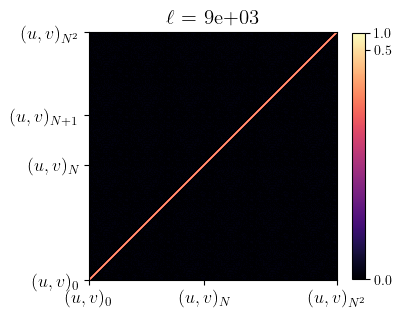

<Figure size 640x480 with 0 Axes>

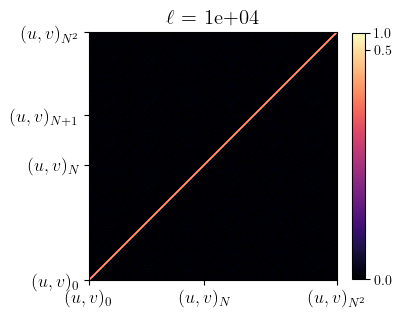

<Figure size 640x480 with 0 Axes>

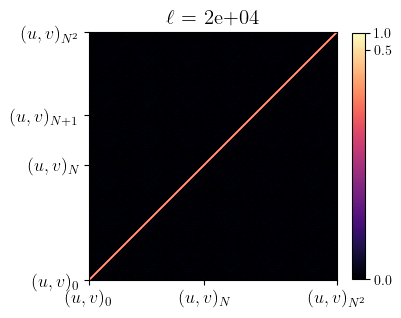

<Figure size 640x480 with 0 Axes>

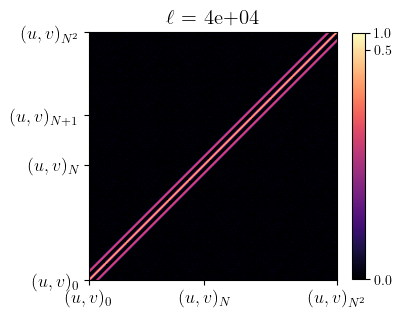

<Figure size 640x480 with 0 Axes>

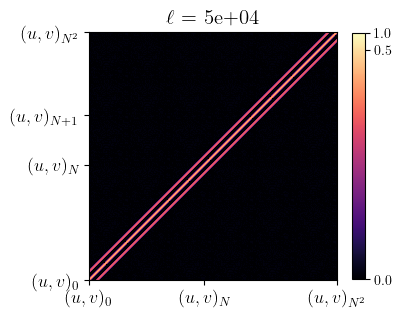

<Figure size 640x480 with 0 Axes>

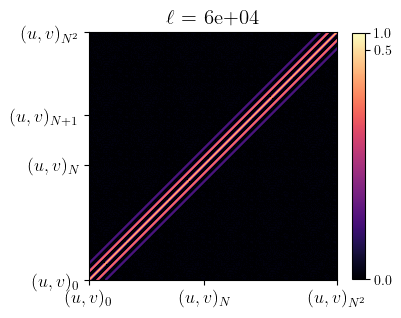

In [77]:
for param in params:
        matrixW = Wendland(param['l'])
        plt.clf()
        plt.figure(figsize=(4,4))

        vmin_val = matrixSE.min()
        vmax_val = matrixSE.max()
        mid_val = (vmin_val + vmax_val) / 2


        im = plt.imshow(matrixW, origin='lower',
                        cmap='magma', 
                        norm=PowerNorm(gamma=0.1, vmin=vmin_val, vmax=vmax_val))

        plt.xticks(tick_positions_x, tick_labels_x, size=13)
        plt.yticks(tick_positions_y, tick_labels_y, size=13)

        cbar = plt.colorbar(im, shrink=0.8, ticks=[vmin_val, mid_val, vmax_val])

        plt.xlim(0, 1500)
        plt.ylim(0, 1500)
        plt.title(r'Wendland', size=15)
        plt.title(r'$\ell$ = ' + f'{param['l']:.0e} ', size = 15)
        plt.show()
    

## Frank for differents $\ell$

In [83]:
frank2d_objects = []
times = []

In [84]:
import math
N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [85]:
for i in range(len(params)):
    start = time.time()
    frank2d = Frank2D(N, Rmax)
    frank2d.fit(data = uvtable, kernel_params = params[i], rtol = 1e-8)
    l_i = params[i]['l']

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l ={l_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 9000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.75 seconds
        +  Building system = 0.01  min |  0.75 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]

            +  BiCGStab = 0.00  min |  0.05 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.10  min |  5.97 seconds
--> times building full visibility model = 0.10  min |  5.98 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l =9000.0 took 8.666101932525635 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.80 seconds
        +  Building system = 0.01  min |  0.80 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 1/50000 [00:00<1:27:26,  9.53 iterations/s]

...

            +  BiCGStab = 0.20  min |  11.88 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of r',
 'final_tol': 7.435963551417657,
 'iterations': 160,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  6.96 seconds
--> times building full visibility model = 0.12  min |  6.99 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l =50000.0 took 23.67331027984619 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.06 seconds
        +  Building system = 0.04  min |  2.12 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 225/50000 [00:21<1:18:38, 10.55 iterations/s]


            +  BiCGStab = 0.36  min |  21.34 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 225,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.14  min |  8.43 seconds
--> times building full visibility model = 0.14  min |  8.47 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l =56439.474897224536 took 35.898011207580566 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 100000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.10  min |  5.91 seconds
        +  Building system = 0.10  min |  6.18 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   4%|▍         | 2082/50000 [08:32<3:16:30,  4.06 iterations/s]


            +  BiCGStab = 8.54  min |  512.28 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 2082,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.20  min |  11.70 seconds
--> times building full visibility model = 0.20  min |  11.84 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l =100000.0 took 538.0087397098541 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


### Try $\ell$ = 2e5 -> takes more than 100 mins!

In [32]:
l_6 = 2e5
params_6 = { 'm': param_N80['m'], 'c': param_N80['c'], 'l': l_6 } 

start = time.time()
frank2d_6 = Frank2D(N, rout)
frank2d_6.fit(data = uvtable, kernel_params = params_6, rtol = 1e-8)
end = time.time()
time_6 = end - start
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with l ={l_6} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 200000.0}
===>  Creating sparse linear system...
        + time kernel = 0.25  min |  14.99 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.26  min |  15.42 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-08
         + final tolerance :  1.2212677737961322
                        .... iteration:  0
                              -> actual tol  1.22e+08  versus  1.22e+00
                        .... iteration:  1
                              -> actual tol  9.56e+07  versus  1.22e+00
                        .... iteration:  2
                              -> actual tol  2.13e+07  versus  1.22e+00
                        .... iteration:  3
                              -> actual tol  5.29e+08  versus  1.22e+00
                        .... iteration:  4
             

KeyboardInterrupt: 

### Plot

In [86]:
ls

[9000.0, 10000.0, 20000.0, 40000.0, 50000.0, 56439.474897224536, 100000.0]

In [87]:
times

[8.666101932525635,
 8.989279747009277,
 9.9624502658844,
 16.322237253189087,
 23.67331027984619,
 35.898011207580566,
 538.0087397098541]

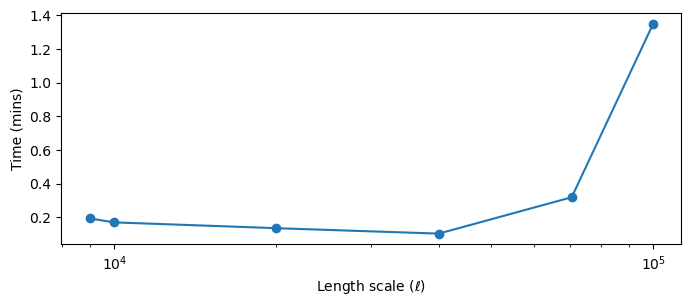

In [116]:
plt.figure(figsize=(8,3))
plt.plot(ls, np.array(times)/60, marker='o')
plt.xscale('log')
plt.xlabel(r'Length scale ($\ell$)')
plt.ylabel('Time (mins)')
plt.show()

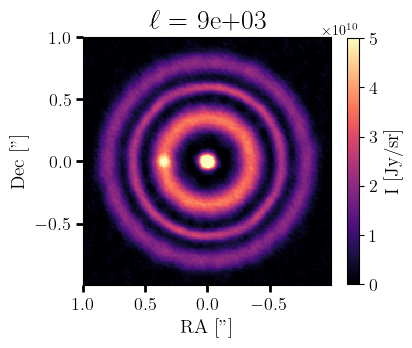

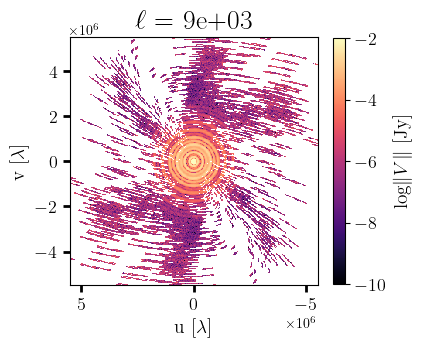

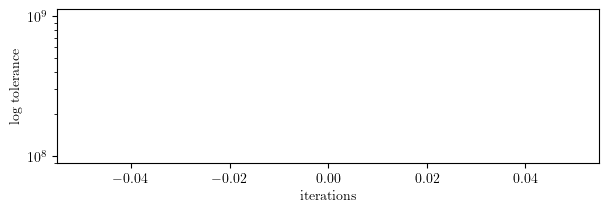

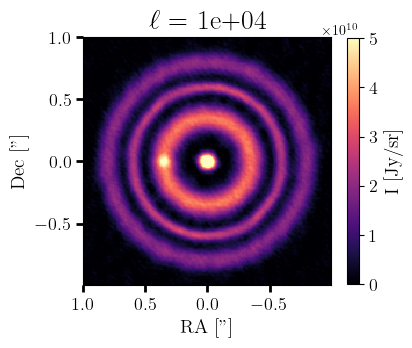

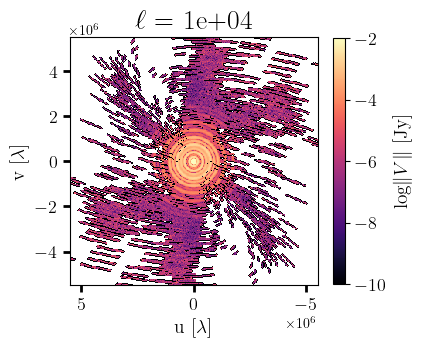

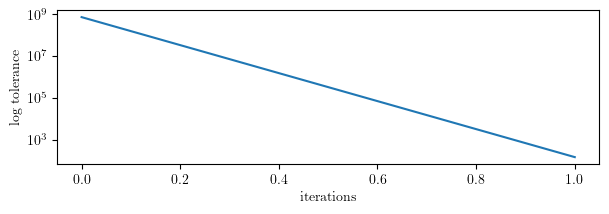

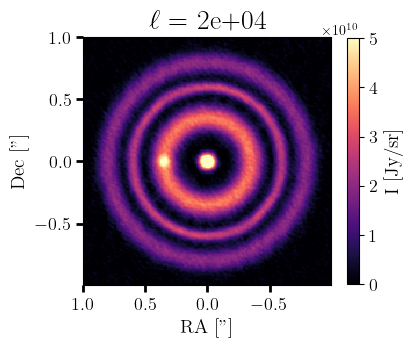

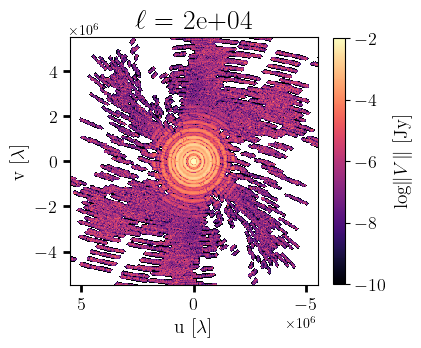

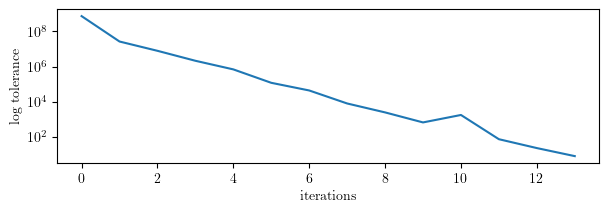

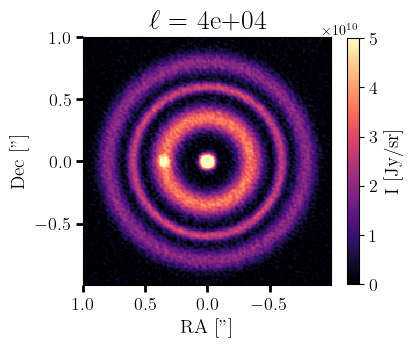

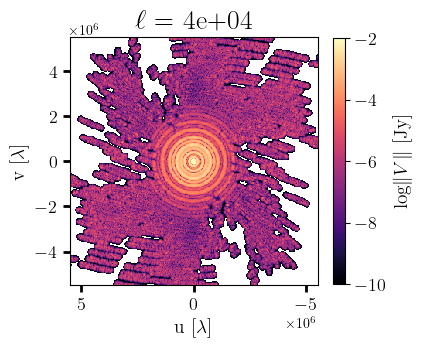

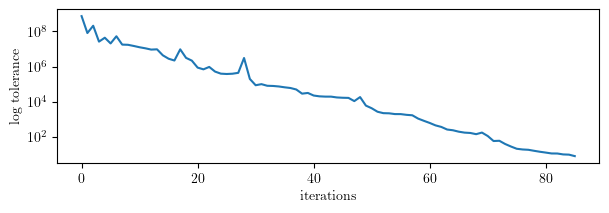

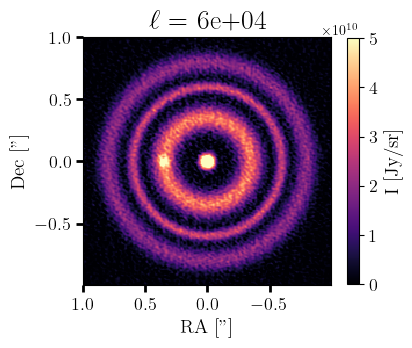

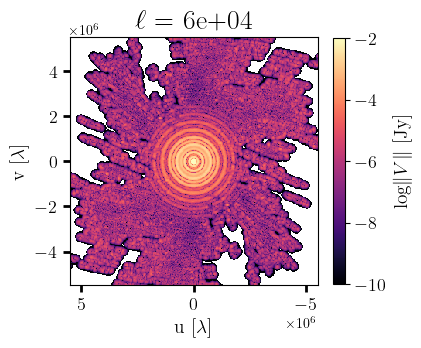

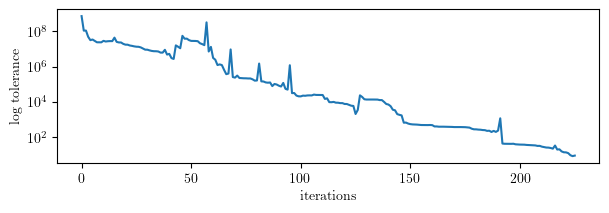

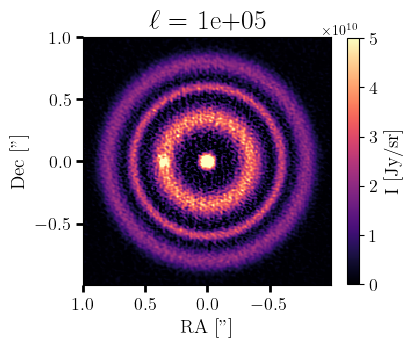

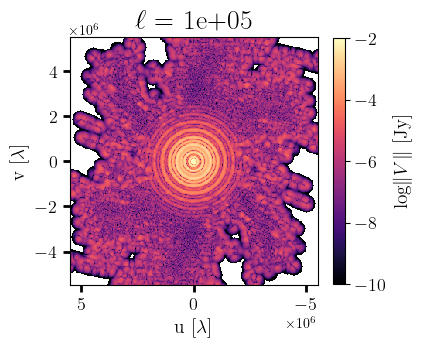

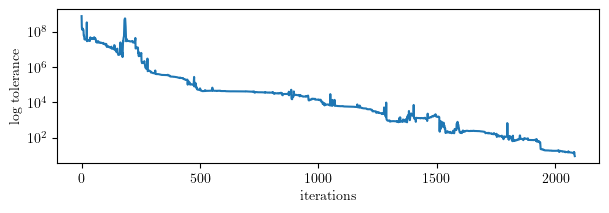

In [49]:
for i in range(len(ls)):
    frank2d = frank2d_objects[i]
    Plot_ = Plot(frank2d, geom)
    Plot_.intensity(fig_size = 4, vmax=5e10, gamma = 1, zoom = 3, title = r'' + f'$\ell$ = {ls[i]:.0e}')
    Plot_.visibility(fig_size = 4, zoom =2,   title = r'' + f' $\ell$ = {ls[i]:.0e}')
    Plot_.cg_tolerance()